# Sheet II.2 (part 1) --- HT26

## Question 1.

We loop through $n$ digits, each requiring a multiplication with $n$ digits. A subseqeuent constant time addition follows each single digit multiplication.

Thus we have $O(n^2)$.

## Question 2.

Newton's method in root finding aims to find $f(\alpha) = 0$.


If we consider the first-order Taylor approximation around the current iterate $x_k$, then $f(x) = f(x_k) + f'(x_k) (x - x_k)$. If we want $f(x)$ to be zero, we have $$ -\frac{f(x_k)}{f'(x_k)} = x - x_k$$
In the hopes that x is then closer to $\alpha$, we take the method to be
$$ x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$$

Recall that convergence is given by $$ |e_{k+1}| \approx \mu |e_k|^q$$


### (a)

Let $f \in C^\infty([a, b])$. Assume that Newton’s method from a fixed initial guess $x_0 \in [a, b]$ gives a sequence of iterates which remain in $[a, b]$ and converges to $\alpha \in [a, b]$.

We know that for some $\xi_k \in (\alpha, x_k)$
$$ f(\alpha) = 0 = f(x_k) + f'(x_k)(\alpha - x_k) + \frac{1}{2}f''(\xi_k)(\alpha - x_k)^2$$

This rearranges to
$$ x_k  -\frac{f(x_k)}{f'(x_k)} - \alpha = \frac{f''(\xi_k)}{2 f'(x_k)} (\alpha - x_k)^2$$

Letting $e_k = x_k - \alpha$ be the error
$$ e_{k+1} = \frac{f''(\xi_k)}{2 f'(x_k)} e_k^2 $$

We note that $f'(\alpha) \ne 0$, and so if we remain in $[a, b]$ and converge to $\alpha$ then for some M,
$$ |e_{k+1}| \le M |e_k|^2$$
and so we have (at least) quadratic convergence. We say at least since we don't know much about $M$ besides that it's bounded.

### (b)

Clearly, if $f'(\alpha) = 0$ we have no bound on $M$.

We explore now the first-order Taylor expansion of $f'$ around $\alpha$, given by

$$ f'(x_k) = f'(\alpha) + f''(\alpha)(x_k - \alpha) = 0 + f''(\alpha) e_k$$

Thus
$$ -e_{k+1} = \frac{f''(\xi_k)}{2 [f''(\alpha)e_k]} e_k^2 = \dfrac{1}{2} e_k$$
$$ |e_{k+1}| = \dfrac{1}{2} |e_k| $$
and so the error converges to 0 with linear convergence (rate 1/2)

### (c)

If $f''(\alpha) = 0$, for the denominator we now need the second-order Taylor expansion of $f'$ around $\alpha$, given by
$$ f'(x_k) = f'(\alpha) + f''(\alpha)(x_k - \alpha) + \dfrac{1}{2} f'''(\alpha)(x_k - \alpha)^2  = \dfrac{1}{2} f'''(\alpha) e_k^2 $$

As for the numerator, recall that $\xi$ comes from our original Taylor expansion of $f$ around the current iterate
$$ f(\alpha) = 0 = f(x_k) + f'(x_k)(\alpha - x_k) + \frac{1}{2}f''(\xi_k)(\alpha - x_k)^2$$
which is no longer sufficient. We now redefine as
$$ f(\alpha) = 0 = f(x_k) + f'(x_k)(\alpha - x_k) + \frac{1}{2}f''(x_k)(\alpha - x_k)^2 + \frac{1}{6}f'''(\xi_k)(\alpha - x_k)^3$$

If we look for the errors again, we get
$$ e_{k+1} = \dfrac{f''(x_k)}{2 f'(x_k)} e_k^2 - \dfrac{f'''(\xi_k)}{6 f'(x_k)} e_k^3$$

The alternating signs arise from $(\alpha - x_k)^n = (-e_k)^n$

We also need the first-order Taylor expansion of $f''$ around $\alpha$, given by
$$ f''(x_k) = f''(\alpha) + f'''(\alpha) (x_k - \alpha) = f'''(\alpha) e_k $$

Thus
$$ e_{k+1} = \frac{f'''(\alpha) e_k}{2 \cdot \frac{1}{2}f'''(\alpha)e_k^2} e_k^2 - \dfrac{f'''(\xi_k)}{6 \cdot \frac{1}{2}f'''(\alpha)e_k^2}e_k^3$$

$$ e_{k+1} = e_k - \dfrac{1}{3}e_k = \dfrac{2}{3} e_k$$
or
$$ |e_{k+1}| = \dfrac{2}{3}|e_k| $$
which is linear convergence with rate 2/3.

### (d)

We need to use:
$$ e_{k+1} = \dfrac{f''(x_k)}{2 f'(x_k)} e_k^2 - \dfrac{f'''(\xi_k)}{6 f'(x_k)} e_k^3$$
The first term cancels to zero, and similarly to (a) we don't know too much about the other term. Given the fact we converge though, we can say that for some $M$,
$$ |e_{k+1}| \le M |e_k|^3 $$
and so we have (at least) cubic convergence.

## Question 3.

In [68]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science"])

In [69]:
def newtons_root_finding(x0, f, f_prime, tolerance=1e-8, epsilon=1e-5, max_iterations=1000):
    for _ in range(max_iterations):
        y = f(x0)
        y_prime = f_prime(x0)

        if np.abs(y) <= tolerance:
            # if converged, return root
            return x0

        if np.abs(y_prime) < epsilon:
            # if f' is zero, exit algorithm
            raise ValueError("Derivative is zero. No solution found.")

        x1 = x0 - y / y_prime  # update step
        x0 = x1
    
    print(type(x0))
    print(f"Last approximation: x = {x0:.2e}")
    raise ValueError("Maximum iterations reached. No solution found.")

### (a) $f(x) = \sin(x) \sinh(x) $

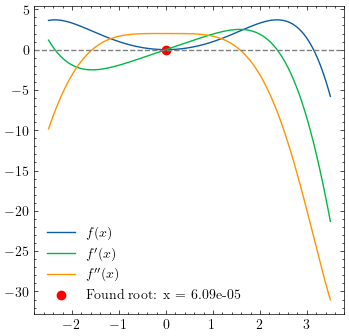

In [70]:
x = sp.symbols('x')

_f = sp.sin(x) * sp.sinh(x)
f = sp.lambdify(x, _f, 'numpy')

_fp = sp.diff(_f, x)
fp = sp.lambdify(x, _fp, 'numpy')

_fpp = sp.diff(_fp, x)
fpp = sp.lambdify(x, _fpp, 'numpy')

x0 = 0.5
xs = np.linspace(x0 - 3, x0 + 3, 200)
ys = f(xs)
yps = fp(xs)
ypps = fpp(xs)

root = newtons_root_finding(x0, f, fp)

fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(xs, ys, label='$f(x)$')
ax.plot(xs, yps, label="$f'(x)$")
ax.plot(xs, ypps, label="$f''(x)$")

ax.axhline(0, color='gray', linestyle='--')
ax.scatter(root, f(root), color='red', label=f'Found root: x = {root:.2e}')
ax.legend()

### (b) $x - \sin(x)$

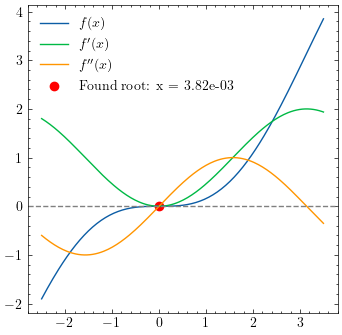

In [71]:
x = sp.symbols('x')

_f = x - sp.sin(x)
f = sp.lambdify(x, _f, 'numpy')

_fp = sp.diff(_f, x)
fp = sp.lambdify(x, _fp, 'numpy')

_fpp = sp.diff(_fp, x)
fpp = sp.lambdify(x, _fpp, 'numpy')

x0 = 0.5
xs = np.linspace(x0 - 3, x0 + 3, 200)
ys = f(xs)
yps = fp(xs)
ypps = fpp(xs)

root = newtons_root_finding(x0, f, fp, epsilon=1e-8)

fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(xs, ys, label='$f(x)$')
ax.plot(xs, yps, label="$f'(x)$")
ax.plot(xs, ypps, label="$f''(x)$")

ax.axhline(0, color='gray', linestyle='--')
ax.scatter(root, f(root), color='red', label=f'Found root: x = {root:.2e}')
ax.legend()

### (c) $x \cos(x)$

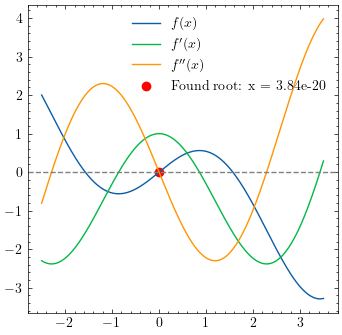

In [72]:
x = sp.symbols('x')

_f = x * sp.cos(x)
f = sp.lambdify(x, _f, 'numpy')

_fp = sp.diff(_f, x)
fp = sp.lambdify(x, _fp, 'numpy')

_fpp = sp.diff(_fp, x)
fpp = sp.lambdify(x, _fpp, 'numpy')

x0 = 0.5
xs = np.linspace(x0 - 3, x0 + 3, 200)
ys = f(xs)
yps = fp(xs)
ypps = fpp(xs)

root = newtons_root_finding(x0, f, fp)

fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(xs, ys, label='$f(x)$')
ax.plot(xs, yps, label="$f'(x)$")
ax.plot(xs, ypps, label="$f''(x)$")

ax.axhline(0, color='gray', linestyle='--')
ax.scatter(root, f(root), color='red', label=f'Found root: x = {root:.2e}')
ax.legend()

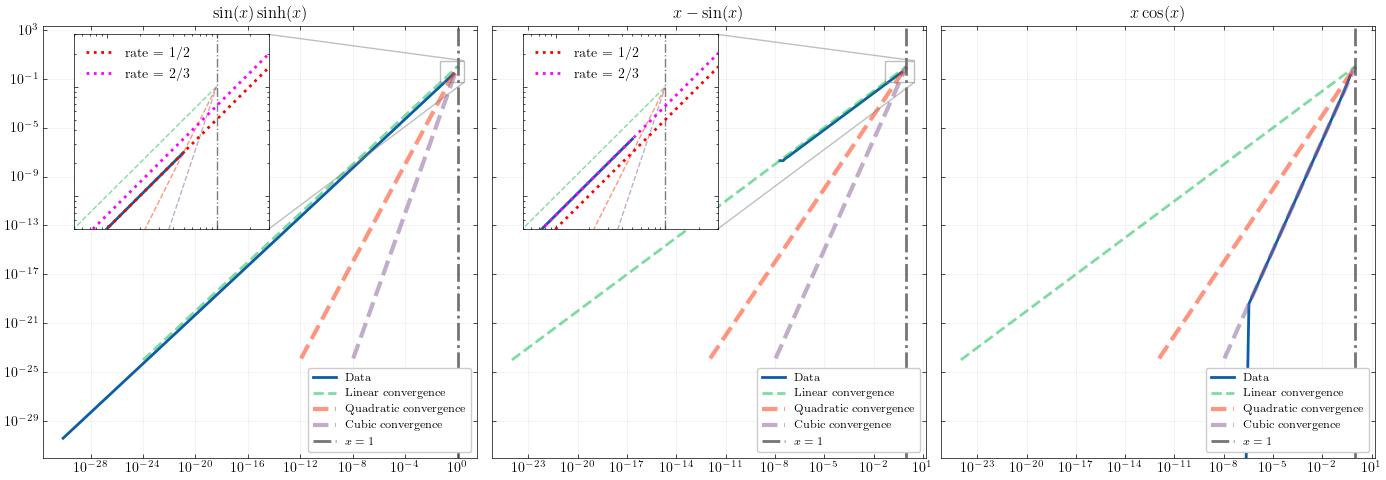

In [73]:
x = sp.symbols('x')

_fs = [
    sp.sin(x) * sp.sinh(x),
    x - sp.sin(x),
    x * sp.cos(x)
]

fs = [sp.lambdify(x, _f, 'numpy') for _f in _fs]
fps = [sp.lambdify(x, sp.diff(_f, x), 'numpy') for _f in _fs]

def get_iterates(f, fp, x0, n):
    _x = x0
    return [_x] + [(_x := _x - f(_x) / fp(_x)) for _ in range(n)]

iterates = [get_iterates(fs, fps, 0.5, 100) for fs, fps in zip(fs, fps)]
errors = [np.abs(iterate) for iterate in iterates]

titles = [
    r"$\sin (x) \sinh (x)$",
    r"$x - \sin (x)$",
    r"$x \cos (x)$"
]

fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for i, ax in enumerate(axs):
    ax.loglog(np.abs(errors[i][:-1]), np.abs(errors[i][1:]), 'C0-', linewidth=2, label='Data')
    
    grid = np.logspace(np.log10(1e-24), 0, 200)
    ax.loglog(grid, grid, 'C1--', linewidth=2, alpha=0.5, label='Linear convergence')
    ax.loglog(grid[grid**2 >= grid.min()], grid[grid**2 >= grid.min()]**2, 'C3--', linewidth=3, alpha=0.5, label='Quadratic convergence')
    ax.loglog(grid[grid**3 >= grid.min()], grid[grid**3 >= grid.min()]**3, 'C4--', linewidth=3, alpha=0.5, label='Cubic convergence')
    ax.axvline(1, color='C5', linestyle='dashdot', alpha=0.75, linewidth=2, label=r"$x=1$")

    if i < 2:
        ax_ins = ax.inset_axes([0.07, 0.53, 0.45, 0.45])
        ax_ins.loglog(np.abs(errors[i][:-1]), np.abs(errors[i][1:]), 'C0-', linewidth=2)
        ax_ins.loglog(grid, grid, 'C1--', linewidth=1, alpha=0.5)
        ax_ins.loglog(grid, grid**2, 'C3--', linewidth=1, alpha=0.5)
        ax_ins.loglog(grid, grid**3, 'C4--', linewidth=1, alpha=0.5)
        ax_ins.axvline(1, color='C5', linestyle='dashdot', alpha=0.7)
        grid = np.logspace(np.log10(1e-2), 2, 50)
        ax_ins.loglog(grid, 0.5 * grid, color='red', linestyle="dotted", linewidth=2, label="rate = 1/2")
        ax_ins.loglog(grid, 2 / 3 * grid, color='fuchsia', linestyle="dotted", linewidth=2, label="rate = 2/3")
        ax_ins.legend()
        ax_ins.set_xlim(0.05, 3.0)
        ax_ins.set_ylim(0.05, 3.0)
        ax_ins.set_xticklabels([])
        ax_ins.set_yticklabels([])
        ax.indicate_inset_zoom(ax_ins, edgecolor="grey")

    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.set_title(titles[i])
    ax.legend(loc='lower right', facecolor='white', framealpha=1.0, frameon=True, fontsize='small')

plt.tight_layout()

In [74]:
def minimum(f, x0, **kwards):
    _fp = sp.diff(f, x)
    _fpp = sp.diff(_fp, x)
    
    fp = sp.lambdify(x, _fp, 'numpy')
    fpp = sp.lambdify(x, _fpp, 'numpy')
    
    return newtons_root_finding(x0, fp, fpp, **kwards)

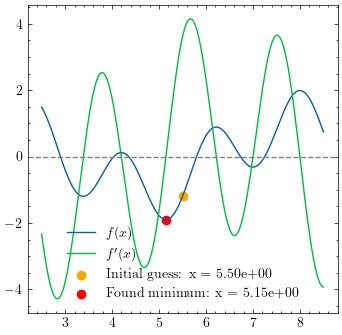

In [75]:
x = sp.symbols('x')

_f = sp.sin(x) + sp.sin(10 * x / 3)
f = sp.lambdify(x, _f, 'numpy')

_fp = sp.diff(_f, x)
fp = sp.lambdify(x, _fp, 'numpy')

_fpp = sp.diff(_fp, x)
fpp = sp.lambdify(x, _fpp, 'numpy')

x0 = 5.5
xs = np.linspace(x0 - 3, x0 + 3, 200)
ys = f(xs)
yps = fp(xs)
ypps = fpp(xs)

xmin = minimum(f=_f, x0=x0)

fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(xs, ys, label='$f(x)$')
ax.plot(xs, yps, label="$f'(x)$")
# ax.plot(xs, ypps, label="$f''(x)$")

ax.axhline(0, color='gray', linestyle='--')
ax.scatter(x0, f(x0), color='orange', label=f'Initial guess: x = {x0:.2e}')
ax.scatter(xmin, f(xmin), color='red', label=f'Found minimum: x = {xmin:.2e}')
ax.legend()

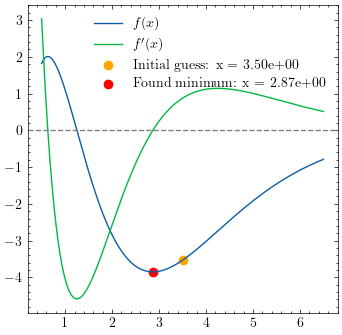

In [76]:
x = sp.symbols('x')

_f = -(16 * x**2 - 24 * x + 5) * sp.exp(-x)
f = sp.lambdify(x, _f, 'numpy')

_fp = sp.diff(_f, x)
fp = sp.lambdify(x, _fp, 'numpy')

_fpp = sp.diff(_fp, x)
fpp = sp.lambdify(x, _fpp, 'numpy')

x0 = 3.5
xs = np.linspace(x0 - 3, x0 + 3, 200)
ys = f(xs)
yps = fp(xs)
ypps = fpp(xs)

xmin = minimum(f=_f, x0=x0, epsilon=1e-10)

fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(xs, ys, label='$f(x)$')
ax.plot(xs, yps, label="$f'(x)$")
# ax.plot(xs, ypps, label="$f''(x)$")

ax.axhline(0, color='gray', linestyle='--')
ax.scatter(x0, f(x0), color='orange', label=f'Initial guess: x = {x0:.2e}')
ax.scatter(xmin, f(xmin), color='red', label=f'Found minimum: x = {xmin:.2e}')
ax.legend()

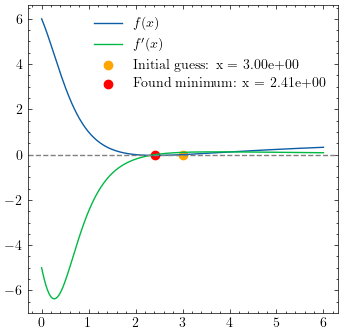

In [77]:
x = sp.symbols('x')

_f = (x**2 - 5 * x + 6) / (x**2 + 1)
f = sp.lambdify(x, _f, 'numpy')

_fp = sp.diff(_f, x)
fp = sp.lambdify(x, _fp, 'numpy')

_fpp = sp.diff(_fp, x)
fpp = sp.lambdify(x, _fpp, 'numpy')

x0 = 3.0
xs = np.linspace(x0 - 3, x0 + 3, 200)
ys = f(xs)
yps = fp(xs)
ypps = fpp(xs)

xmin = minimum(f=_f, x0=x0, epsilon=1e-10)

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(xs, ys, label='$f(x)$')
ax.plot(xs, yps, label="$f'(x)$")
ax.axhline(0, color='gray', linestyle='--')
ax.scatter(x0, f(x0), color='orange', label=f'Initial guess: x = {x0:.2e}')
ax.scatter(xmin, f(xmin), color='red', label=f'Found minimum: x = {xmin:.2e}')
ax.legend()

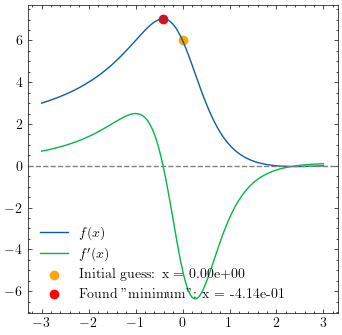

In [78]:
x = sp.symbols('x')

_f = (x**2 - 5 * x + 6) / (x**2 + 1)
f = sp.lambdify(x, _f, 'numpy')

_fp = sp.diff(_f, x)
fp = sp.lambdify(x, _fp, 'numpy')

_fpp = sp.diff(_fp, x)
fpp = sp.lambdify(x, _fpp, 'numpy')

x0 = 0.0
xs = np.linspace(x0 - 3, x0 + 3, 200)
ys = f(xs)
yps = fp(xs)
ypps = fpp(xs)

xmin = minimum(f=_f, x0=x0, epsilon=1e-10)

fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(xs, ys, label='$f(x)$')
ax.plot(xs, yps, label="$f'(x)$")
# ax.plot(xs, ypps, label="$f''(x)$")

ax.axhline(0, color='gray', linestyle='--')
ax.scatter(x0, f(x0), color='orange', label=f'Initial guess: x = {x0:.2e}')
ax.scatter(xmin, f(xmin), color='red', label=f'Found "minimum": x = {xmin:.2e}')
ax.legend()

We cannot do `x1 = x0 - y / y_prime`, when `y_prime` is a vector

We see that this is
$$ x_1 = x_0 - [\nabla^2 f]^{-1} \nabla f $$
and is fundamentally an $Ax = b$ problem. We can solve for $x$ via
$$[\nabla^2 f] x = \nabla f \implies x = [\nabla^2 f]^{-1} \nabla f$$

In [79]:
def newtons_root_finding_mv(x0, f, f_prime, tolerance=1e-8, epsilon=1e-5, max_iterations=1000):
    for _ in range(max_iterations):
        y = f(x0)
        y_prime = f_prime(x0)

        if np.linalg.norm(y) <= tolerance:
            return x0

        if np.linalg.norm(y_prime) < epsilon:
            raise ValueError("Derivative is zero. No solution found.")

        delta = np.linalg.solve(y_prime, y)
        x1 = x0 - delta.flatten()
        x0 = x1
    
    print(type(x0))
    print(f"Last approximation: x = {x0:.2e}")
    raise ValueError("Maximum iterations reached. No solution found.")

In [80]:
def minimum_mv(f, x0, **kwargs):

    x, y = sp.symbols('x y')
    
    variables = (x, y)
    
    _grad = sp.Matrix([f.diff(v) for v in variables])
    _hess = sp.hessian(f, variables)
    
    grad = sp.lambdify([variables], _grad, 'numpy')
    hess = sp.lambdify([variables], _hess, 'numpy')
    
    return newtons_root_finding_mv(x0, grad, hess, **kwargs)

In [81]:
x, y = sp.symbols('x y')
_f_rosen = (1 - x)**2 + 100 * (y - x**2)**2

x0_vec = np.array([-1.2, 1.0])
xmin = minimum_mv(_f_rosen, x0_vec, epsilon=1e-8)

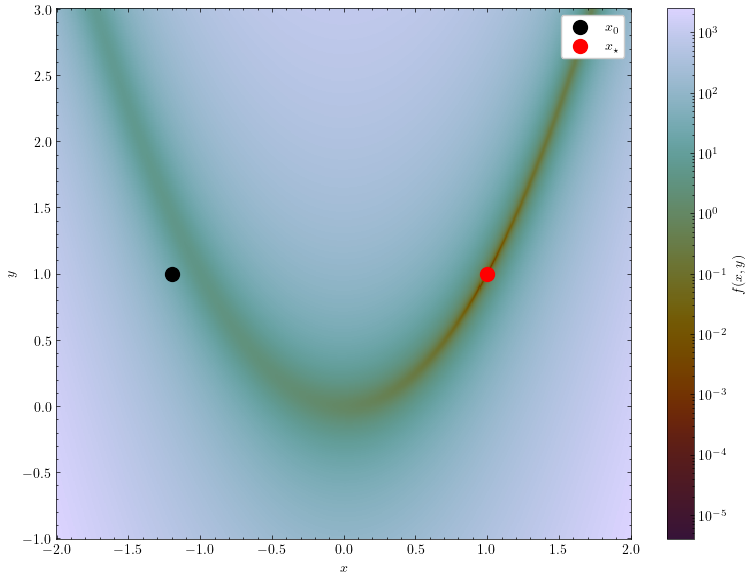

In [82]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from cmap import Colormap

cmap = Colormap("crameri:glasgow").to_mpl()

x = np.linspace(-2, 2, 500)
y = np.linspace(-1, 3, 500)
X, Y = np.meshgrid(x, y)

Z = (1 - X)**2 + 100 * (Y - X**2)**2

plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(X, Y, Z, norm=LogNorm(), cmap=cmap, shading='auto')
plt.colorbar(pcm, label='$f(x, y)$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.scatter(x0_vec[0], x0_vec[1], color='black', s=100, label=r"$x_0$") 
plt.scatter(xmin[0], xmin[1], color='red', s=100, label=r"$x_\star$") 
plt.legend(loc='upper right', facecolor='white', framealpha=1.0, frameon=True)
plt.tight_layout()
plt.show()